##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
!pip install -q opencv-python-headless matplotlib scikit-learn tensorflow yt-dlp


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

In [3]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)


In [ ]:
pip install rarfile


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
DATASET_DIR = "/Users/fellwakh/Documents/GitHub/arti560-computer-vision-labs/lab07-action-recognition/data/UCF11_updated_mpg"

# لو فيه مجلد واحد بس، ادخل فيه تلقائياً
contents = os.listdir(DATASET_DIR)
if len(contents) == 1 and os.path.isdir(os.path.join(DATASET_DIR, contents[0])):
    DATASET_DIR = os.path.join(DATASET_DIR, contents[0])

all_classes = os.listdir(DATASET_DIR)
print("=" * 50)
print("Available Classes in Dataset:")
for cls in sorted(all_classes):
    print(f"  - {cls}")
print("=" * 50)

Available Classes in Dataset:
  - basketball
  - biking
  - diving
  - golf_swing
  - horse_riding
  - soccer_juggling
  - swing
  - tennis_swing
  - trampoline_jumping
  - volleyball_spiking
  - walking


In [10]:
CLASSES_LIST = ["diving", "horse_riding", "volleyball_spiking"]
print(f"\nSelected Classes: {CLASSES_LIST}\n")

# Preprocess the dataset and extract frames
image_height, image_width = 64, 64
max_images_per_class = 8000
model_output_size = len(CLASSES_LIST)

def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    while True:
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255
        frames_list.append(normalized_frame)
    video_reader.release()
    return frames_list

def create_dataset():
    temp_features = []
    features = []
    labels = []
    class_frame_counts = {}

    for class_index, class_name in enumerate(CLASSES_LIST):
        class_path = os.path.join(DATASET_DIR, class_name)

        for root, dirs, files in os.walk(class_path):
            for file_name in files:
                if file_name.lower().endswith((".mpg", ".avi", ".mp4", ".mov")):
                    video_file_path = os.path.join(root, file_name)
                    frames = frames_extraction(video_file_path)
                    temp_features.extend(frames)

        class_frame_counts[class_name] = len(temp_features)
        sample_size = min(len(temp_features), max_images_per_class)
        features.extend(random.sample(temp_features, sample_size))
        labels.extend([class_index] * sample_size)
        temp_features.clear()

    # Print extraction summary as table
    print("=" * 45)
    print(f"{'Class':<25} {'Total Frames':>12} {'Sampled':>6}")
    print("=" * 45)
    for cls, count in class_frame_counts.items():
        sampled = min(count, max_images_per_class)
        print(f"{cls:<25} {count:>12,} {sampled:>6,}")
    print("=" * 45)

    features = np.asarray(features)
    labels = np.array(labels)
    return features, labels


features, labels = create_dataset()
one_hot_encoded_labels = to_categorical(labels)


Selected Classes: ['diving', 'horse_riding', 'volleyball_spiking']

Class                     Total Frames Sampled
diving                          26,740  8,000
horse_riding                    38,974  8,000
volleyball_spiking              12,852  8,000


In [11]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels, test_size=0.2, shuffle=True, random_state=seed_constant)

print(f"\nTraining samples : {len(features_train):,}")
print(f"Testing samples  : {len(features_test):,}\n")


Training samples : 19,200
Testing samples  : 4,800



In [12]:
def create_model():
    model = Sequential()
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(image_height, image_width, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation='softmax'))
    model.summary()
    return model

model = create_model()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

In [13]:
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=15,
                                        mode='min', restore_best_weights=True)

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=["accuracy"])

model_training_history = model.fit(
    x=features_train, y=labels_train,
    epochs=30, batch_size=4,
    shuffle=True, validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.7501 - loss: 0.6163 - val_accuracy: 0.7977 - val_loss: 0.4770
Epoch 2/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.8609 - loss: 0.3911 - val_accuracy: 0.8677 - val_loss: 0.4332
Epoch 3/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.9032 - loss: 0.2872 - val_accuracy: 0.7102 - val_loss: 0.9849
Epoch 4/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9245 - loss: 0.2283 - val_accuracy: 0.8555 - val_loss: 0.5158
Epoch 5/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9403 - loss: 0.1902 - val_accuracy: 0.9755 - val_loss: 0.0931
Epoch 6/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9478 - loss: 0.1714 - val_accuracy: 0.8664 - val_loss: 0.3559
Epoch 7/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9533 - loss: 0.1485 - val_accuracy: 0.9609 - val_loss: 0.1083
Epoch 8/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9596 -

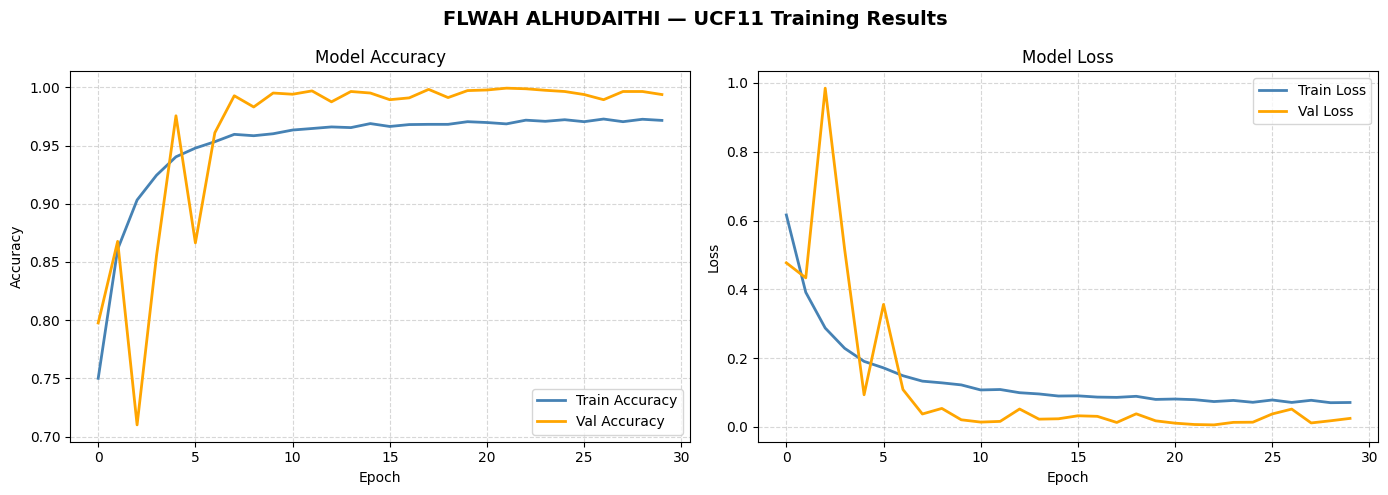

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FLWAH ALHUDAITHI — UCF11 Training Results', fontsize=14, fontweight='bold')

axes[0].plot(model_training_history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(model_training_history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(model_training_history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(model_training_history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('FLWAH_ALHUDAITHI_training_plot.png', dpi=150)
plt.show()

In [30]:
loss, accuracy = model.evaluate(features_test, labels_test)

# Results table
print("\n" + "=" * 40)
print("         TEST EVALUATION RESULTS")
print("         FLWAH ALHUDAITHI — UCF11")
print("=" * 40)
results_df = pd.DataFrame({
    'Metric': ['Test Loss', 'Test Accuracy'],
    'Value': [f"{loss:.4f}", f"{accuracy * 100:.2f}%"]
})
print(results_df.to_string(index=False))
print("=" * 40)

150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9979 - loss: 0.0124

         TEST EVALUATION RESULTS
         FLWAH ALHUDAITHI — UCF11
       Metric  Value
    Test Loss 0.0124
Test Accuracy 99.79%


In [31]:
student_name = "FLWAH_ALHUDAITHI"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"\nModel saved as: {save_path}\n")


Model saved as: FLWAH_ALHUDAITHI_ucf11_model.h5



In [32]:
def predict_video(stream_url, num_frames=16):
    if stream_url is None:
        return None

    cap = cv2.VideoCapture(stream_url)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        total_frames = 300

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (image_height, image_width))
            frame = frame / 255.0
            frames.append(frame)
    cap.release()

    if not frames:
        return None

    frames_array = np.array(frames)                      # (N, 64, 64, 3)
    preds = model.predict(frames_array, verbose=0)       # (N, 3)
    avg_preds = preds.mean(axis=0)                       # average across frames
    pred_idx = np.argmax(avg_preds)
    confidence = avg_preds[pred_idx]
    predicted_class = CLASSES_LIST[pred_idx]

    return predicted_class, confidence

In [17]:
!pip install yt-dlp


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [27]:
# pip install yt-dlp
import yt_dlp

def get_youtube_stream_url(youtube_url):
    ydl_opts = {'format': 'best[ext=mp4]', 'quiet': True}
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(youtube_url, download=False)
        return info['url']

test_videos = {
    "diving"            : "https://youtube.com/shorts/28K8jEYtYd8?si=YHIL5qTf71WC4sCD",
    "horse_riding"      : "https://youtube.com/shorts/Iggi7UGJIeI?si=P8cklJNhzTfw-E0l",
    "volleyball_spiking": "https://youtube.com/shorts/HkYsfGkpYjA?si=Vm0BEKJM4-sC5H-S"
}

print("=" * 60)
print(f"{'Video':<25} {'Predicted Action':<22} {'Confidence':>10}")
print("=" * 60)

results = []
for class_name, yt_url in test_videos.items():
    stream_url = get_youtube_stream_url(yt_url)
    result = predict_video(stream_url)
    if result:
        predicted_class, confidence = result
        print(f"{class_name:<25} {predicted_class:<22} {confidence*100:>9.2f}%")
        results.append({'video': class_name, 'class': predicted_class, 'confidence': confidence * 100})
    else:
        print(f"{class_name:<25} {'Failed':<22} {'N/A':>10}")

print("=" * 60)

Video                     Predicted Action       Confidence


diving                    diving                     87.58%


horse_riding              horse_riding              100.00%


volleyball_spiking        volleyball_spiking        100.00%


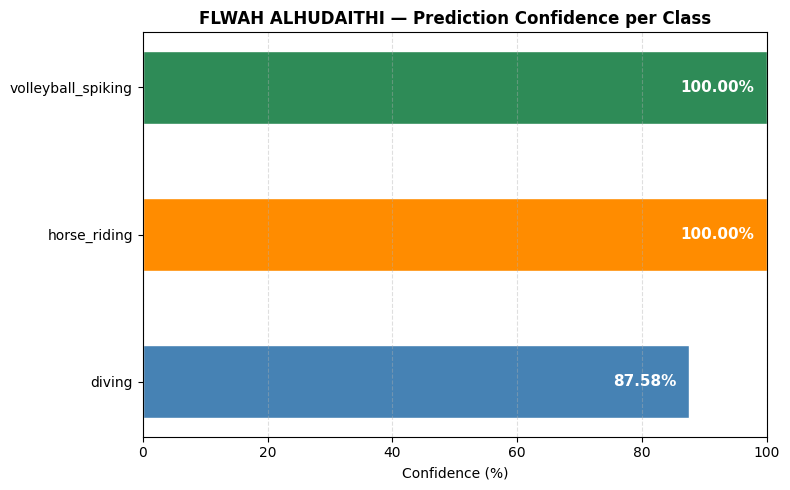

In [33]:
if results:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['steelblue', 'darkorange', 'seagreen']
    bars = ax.barh([r['class'] for r in results],
                   [r['confidence'] for r in results],
                   color=colors, edgecolor='white', height=0.5)
    for bar, r in zip(bars, results):
        ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
                f"{r['confidence']:.2f}%", va='center', ha='right',
                color='white', fontweight='bold', fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Confidence (%)')
    ax.set_title('FLWAH ALHUDAITHI — Prediction Confidence per Class', fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('FLWAH_ALHUDAITHI_predictions.png', dpi=150)
    plt.show()